# CSE457 - XỬ LÝ ÂM THANH VÀ TIẾNG NÓI
# LAB 1: PHÂN TÍCH VÀ XỬ LÝ TÍN HIỆU ÂM THANH SỐ

Sinh viên: Vũ Văn Đạt  
MSSV: 2351260645


In [9]:

import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
from scipy import signal
import soundfile as sf
import os

os.makedirs("figures", exist_ok=True)
os.makedirs("audio", exist_ok=True)


## A. Audio metadata

In [10]:

# Đọc file âm thanh đầu vào bằng thư viện Librosa
# x: mảng dữ liệu chứa giá trị biên độ của tín hiệu âm thanh
# Fs: tần số lấy mẫu (Sampling Rate) của file âm thanh
#
# sr=None:
# Giữ nguyên tần số lấy mẫu gốc của file,
# không tự động chuyển đổi về giá trị mặc định của Librosa (22050 Hz)
#
# mono=True:
# Chuyển tín hiệu âm thanh về dạng 1 kênh (mono)
# giúp thuận tiện cho việc phân tích tín hiệu

x, Fs = librosa.load(
    "audio/input.mp3",
    sr=None,
    mono=True
)


# Tính thời lượng của tín hiệu âm thanh
#
# Công thức:
# Duration = Tổng số mẫu tín hiệu / Tần số lấy mẫu
#
# len(x): số lượng mẫu âm thanh
# Fs: số mẫu được lấy trong 1 giây

duration = len(x) / Fs


# In ra tần số lấy mẫu của tín hiệu
#
# Sampling rate cho biết số lần lấy mẫu tín hiệu trong 1 giây
# Đơn vị: Hz
#
# Ví dụ:
# Fs = 48000 Hz nghĩa là trong 1 giây có 48000 mẫu âm thanh

print("Sampling rate:", Fs)


# In ra thời lượng của file âm thanh
#
# Duration cho biết độ dài của tín hiệu tính theo giây

print("Duration:", duration, "seconds")


# In ra tổng số mẫu của tín hiệu
#
# Số mẫu càng lớn thì lượng dữ liệu âm thanh càng nhiều

print("Samples:", len(x))


Sampling rate: 48000
Duration: 7.896 seconds
Samples: 379008


## B. Time domain analysis

CÁC THÔNG SỐ MIỀN THỜI GIAN
Peak amplitude : 0.87196994
RMS value      : 0.106860965
Signal Energy  : 4327.993


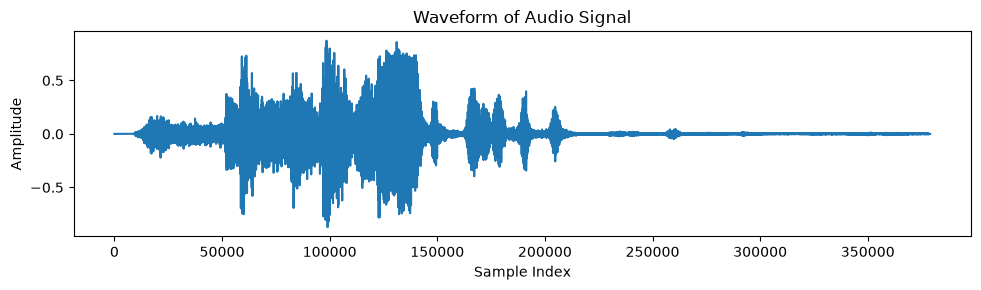

In [11]:
# ============================================================
# B. PHÂN TÍCH TÍN HIỆU TRONG MIỀN THỜI GIAN
# ============================================================

# ------------------------------------------------------------
# 1. Tính giá trị Peak (biên độ cực đại)
#
# Công thức:
#
# Peak = max(|x[n]|)
#
# Trong đó:
# x[n] là giá trị biên độ của mẫu thứ n
#
# Ý nghĩa:
# - Cho biết mức biên độ lớn nhất của tín hiệu.
# - Dùng để kiểm tra hiện tượng clipping
#   (tín hiệu bị vượt quá giới hạn biên độ).
#
# np.abs(x):
# Lấy giá trị tuyệt đối của các mẫu tín hiệu
#
# np.max():
# Lấy giá trị lớn nhất
# ------------------------------------------------------------

peak = np.max(np.abs(x))



# ------------------------------------------------------------
# 2. Tính giá trị RMS (Root Mean Square)
#
# Công thức:
#
# RMS = sqrt(mean(x[n]^2))
#
# Ý nghĩa:
# - Đại diện cho mức năng lượng trung bình của tín hiệu.
# - Với tín hiệu tiếng nói, RMS thể hiện mức độ mạnh/yếu
#   của âm thanh.
#
# Các bước:
# x*x:
# Bình phương từng mẫu tín hiệu
#
# np.mean():
# Tính giá trị trung bình
#
# np.sqrt():
# Lấy căn bậc hai
# ------------------------------------------------------------

rms = np.sqrt(np.mean(x*x))



# ------------------------------------------------------------
# 3. Tính Energy (năng lượng tín hiệu)
#
# Công thức:
#
# Energy = Σ x[n]^2
#
# Ý nghĩa:
# - Đánh giá tổng năng lượng của toàn bộ tín hiệu.
# - Tín hiệu có biên độ lớn sẽ có năng lượng cao hơn.
#
# np.sum():
# Cộng toàn bộ giá trị bình phương của tín hiệu
# ------------------------------------------------------------

energy = np.sum(x*x)



# ------------------------------------------------------------
# 4. Hiển thị kết quả tính toán
# ------------------------------------------------------------

print("="*40)
print("CÁC THÔNG SỐ MIỀN THỜI GIAN")
print("="*40)

print("Peak amplitude :", peak)

print("RMS value      :", rms)

print("Signal Energy  :", energy)

print("="*40)



# ============================================================
# 5. Vẽ dạng sóng Waveform
# ============================================================

plt.figure(figsize=(10,3))


# Biểu diễn sự thay đổi biên độ tín hiệu theo thời gian
#
# Trục X:
# số thứ tự mẫu (sample index)
#
# Trục Y:
# giá trị biên độ của tín hiệu

plt.plot(x)


# Tiêu đề biểu đồ

plt.title("Waveform of Audio Signal")


# Nhãn trục X

plt.xlabel("Sample Index")


# Nhãn trục Y

plt.ylabel("Amplitude")



# Tự động căn chỉnh bố cục hình

plt.tight_layout()



# ------------------------------------------------------------
# Lưu hình ảnh để sử dụng trong báo cáo
#
# dpi=300:
# độ phân giải cao, phù hợp đưa vào báo cáo PDF
# ------------------------------------------------------------

plt.savefig(
    "figures/waveform.png",
    dpi=300,
    bbox_inches="tight"
)



# Hiển thị biểu đồ

plt.show()


## C. FFT analysis

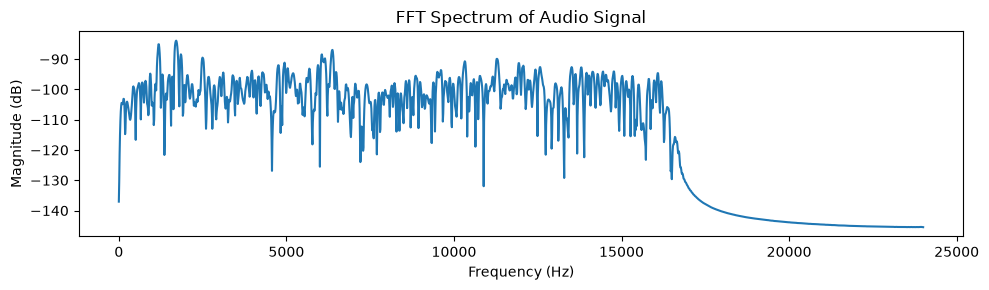

THÔNG SỐ PHÂN TÍCH FFT
Sampling Rate: 48000 Hz
FFT points: 4096
Frequency resolution: 11.719 Hz


In [12]:

# ============================================================
# C. PHÂN TÍCH TÍN HIỆU TRONG MIỀN TẦN SỐ BẰNG FFT
# ============================================================

# ------------------------------------------------------------
# 1. Lựa chọn đoạn tín hiệu để phân tích FFT
#
# FFT thường được thực hiện trên một đoạn tín hiệu ổn định
# thay vì toàn bộ file âm thanh.
#
# Ở đây chọn đoạn đầu tiên có độ dài tối đa 1 giây:
#
# Số mẫu trong 1 giây = Sampling Rate (Fs)
#
# Ví dụ:
# Fs = 48000 Hz
# => lấy 48000 mẫu đầu tiên
#
# min() giúp tránh lỗi nếu file âm thanh ngắn hơn 1 giây.
# ------------------------------------------------------------

segment = x[:min(len(x), Fs)]



# ------------------------------------------------------------
# 2. Khai báo số điểm FFT
#
# NFFT quyết định số lượng điểm khi biến đổi Fourier.
#
# Độ phân giải tần số:
#
# Δf = Fs / NFFT
#
# NFFT càng lớn:
# - Khoảng cách giữa các điểm tần số càng nhỏ
# - Phân tích tần số chi tiết hơn
#
# Tuy nhiên NFFT lớn không làm tăng thông tin thực
# nếu tín hiệu đầu vào không đủ dài.
# ------------------------------------------------------------

NFFT = 4096



# ------------------------------------------------------------
# 3. Áp dụng cửa sổ Hamming trước khi tính FFT
#
# Vấn đề:
# Khi cắt một đoạn tín hiệu, điểm đầu và cuối có thể gây ra
# hiện tượng rò rỉ phổ (Spectral Leakage).
#
# Cửa sổ Hamming giúp giảm ảnh hưởng này bằng cách làm giảm
# biên độ tín hiệu ở hai đầu đoạn phân tích.
#
# np.hamming():
# tạo hàm cửa sổ Hamming
# ------------------------------------------------------------

window = np.hamming(len(segment))


# Nhân tín hiệu với cửa sổ Hamming

windowed_signal = segment * window



# ------------------------------------------------------------
# 4. Tính FFT
#
# np.fft.rfft():
# thực hiện FFT cho tín hiệu thực
#
# Kết quả:
# X chứa các thành phần tần số của tín hiệu.
#
# rfft chỉ lấy nửa phổ dương vì tín hiệu âm thanh là tín hiệu thực.
# ------------------------------------------------------------

X = np.fft.rfft(
    windowed_signal,
    NFFT
)



# ------------------------------------------------------------
# 5. Tạo trục tần số
#
# Công thức:
#
# f = k * Fs/NFFT
#
# np.fft.rfftfreq():
# tạo các giá trị tần số tương ứng với FFT
# ------------------------------------------------------------

freq = np.fft.rfftfreq(
    NFFT,
    1/Fs
)



# ------------------------------------------------------------
# 6. Chuyển biên độ phổ sang đơn vị dB
#
# Công thức:
#
# Magnitude(dB)=20*log10(|X|)
#
# Thêm 1e-12 để tránh log(0)
# ------------------------------------------------------------

magnitude_db = 20*np.log10(
    np.abs(X)+1e-12
)



# ============================================================
# 7. Vẽ phổ FFT
# ============================================================

plt.figure(figsize=(10,3))


# Trục X:
# tần số (Hz)
#
# Trục Y:
# mức năng lượng phổ (dB)

plt.plot(
    freq,
    magnitude_db
)



plt.xlabel(
    "Frequency (Hz)"
)

plt.ylabel(
    "Magnitude (dB)"
)


plt.title(
    "FFT Spectrum of Audio Signal"
)



# Căn chỉnh bố cục

plt.tight_layout()



# Lưu hình để đưa vào báo cáo

plt.savefig(
    "figures/fft.png",
    dpi=300,
    bbox_inches="tight"
)



# Hiển thị kết quả

plt.show()



# ============================================================
# 8. Tính và hiển thị độ phân giải tần số
# ============================================================

frequency_resolution = Fs / NFFT


print("="*50)
print("THÔNG SỐ PHÂN TÍCH FFT")
print("="*50)

print("Sampling Rate:",
      Fs,
      "Hz")

print("FFT points:",
      NFFT)

print("Frequency resolution:",
      round(frequency_resolution,3),
      "Hz")

print("="*50)


## D. STFT Spectrogram

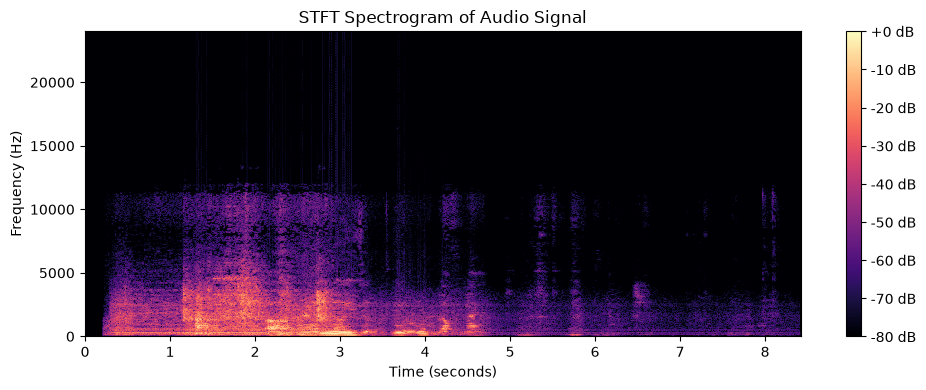

In [13]:

# ============================================================
# D. PHÂN TÍCH TÍN HIỆU BẰNG STFT
# (Short-Time Fourier Transform)
# ============================================================


# ------------------------------------------------------------
# 1. Thực hiện biến đổi STFT
#
# STFT chia tín hiệu âm thanh thành nhiều đoạn nhỏ (frame)
# và thực hiện FFT trên từng đoạn.
#
# Khác với FFT thông thường chỉ cho biết thông tin tần số
# tổng thể, STFT cho biết:
#
# - Thành phần tần số thay đổi như thế nào theo thời gian.
#
#
# Các tham số:
#
# n_fft = 2048:
# Số điểm FFT được sử dụng trong mỗi frame.
# Số điểm càng lớn thì độ phân giải tần số càng cao.
#
#
# hop_length = 480:
# Khoảng cách dịch chuyển giữa hai frame liên tiếp.
#
# Với Fs = 48000 Hz:
#
# 480 / 48000 = 0.01 giây = 10 ms
#
# Nghĩa là mỗi frame cách nhau 10 ms.
#
#
# win_length = 1200:
# Độ dài cửa sổ phân tích.
#
# Với Fs = 48000 Hz:
#
# 1200 / 48000 = 0.025 giây = 25 ms
#
# Đây là kích thước frame phổ biến trong xử lý tiếng nói.
#
#
# window="hamming":
# Sử dụng cửa sổ Hamming nhằm giảm hiện tượng rò rỉ phổ
# (spectral leakage).
# ------------------------------------------------------------


D = librosa.stft(
    x,
    n_fft=2048,
    hop_length=480,
    win_length=1200,
    window="hamming"
)



# ------------------------------------------------------------
# 2. Chuyển đổi biên độ STFT sang đơn vị dB
#
# Kết quả STFT là số phức:
#
# D = Magnitude + Phase
#
# Chúng ta chỉ quan tâm đến độ lớn:
#
# |D|
#
# Sau đó chuyển sang thang logarit dB để dễ quan sát.
#
# Công thức:
#
# S(dB)=20log10(|D|)
#
# ref=np.max:
# chuẩn hóa theo giá trị lớn nhất của phổ.
# ------------------------------------------------------------


S = librosa.amplitude_to_db(
    np.abs(D),
    ref=np.max
)



# ============================================================
# 3. Vẽ Spectrogram
# ============================================================


plt.figure(figsize=(10,4))


# ------------------------------------------------------------
# Hiển thị phổ thời gian - tần số
#
# Trục X:
# thời gian (seconds)
#
# Trục Y:
# tần số (Hz)
#
# Màu sắc:
# mức năng lượng của tín hiệu tại mỗi thời điểm và tần số.
# ------------------------------------------------------------


librosa.display.specshow(
    S,
    sr=Fs,
    x_axis="time",
    y_axis="hz"
)



# Hiển thị thanh màu biểu diễn mức năng lượng

plt.colorbar(
    format="%+2.0f dB"
)



# Tiêu đề biểu đồ

plt.title(
    "STFT Spectrogram of Audio Signal"
)



# Nhãn trục

plt.xlabel(
    "Time (seconds)"
)

plt.ylabel(
    "Frequency (Hz)"
)



# Căn chỉnh bố cục

plt.tight_layout()



# ------------------------------------------------------------
# Lưu hình ảnh phục vụ báo cáo
#
# dpi=300:
# chất lượng cao khi đưa vào PDF
# ------------------------------------------------------------

plt.savefig(
    "figures/spectrogram.png",
    dpi=300,
    bbox_inches="tight"
)



# Hiển thị kết quả

plt.show()


## E. FIR Filtering

Đã lưu file âm thanh sau lọc!


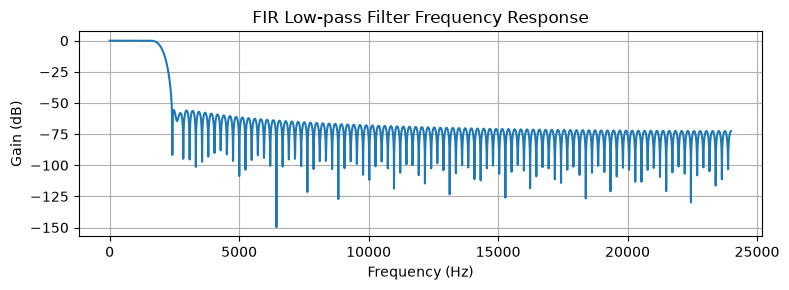

In [14]:

# ============================================================
# F. THIẾT KẾ VÀ ÁP DỤNG BỘ LỌC FIR
# (Finite Impulse Response Filter)
# ============================================================


# ------------------------------------------------------------
# 1. Thiết kế bộ lọc FIR Low-pass
#
# Bộ lọc thông thấp (Low-pass Filter):
# - Cho phép các thành phần tần số thấp đi qua.
# - Loại bỏ các thành phần tần số cao.
#
# Trong xử lý tiếng nói:
# vùng tần số thấp thường chứa nhiều thông tin giọng nói.
#
#
# Hàm signal.firwin():
# Thiết kế bộ lọc FIR bằng phương pháp cửa sổ.
#
# Tham số:
#
# numtaps = 201:
# Số lượng hệ số của bộ lọc.
# Số tap càng lớn:
# - Đáp ứng tần số càng chính xác
# - Nhưng độ trễ xử lý tăng
#
#
# cutoff = 2000 Hz:
# Tần số cắt của bộ lọc.
#
# fs = Fs:
# Tần số lấy mẫu của tín hiệu.
# ------------------------------------------------------------


b_lp = signal.firwin(
    numtaps=201,
    cutoff=2000,
    fs=Fs
)



# ------------------------------------------------------------
# 2. Áp dụng bộ lọc Low-pass lên tín hiệu
#
# signal.lfilter():
# Thực hiện phép lọc theo phương trình sai phân:
#
# y[n] = Σ b[k]x[n-k]
#
# Trong đó:
# b[k] là các hệ số của bộ lọc FIR
# x[n] là tín hiệu đầu vào
#
# ------------------------------------------------------------

y_lp = signal.lfilter(
    b_lp,
    [1],
    x
)



# ============================================================
# 3. Thiết kế bộ lọc FIR High-pass
# ============================================================


# ------------------------------------------------------------
# Bộ lọc thông cao (High-pass Filter):
#
# - Cho phép thành phần tần số cao đi qua.
# - Loại bỏ thành phần tần số thấp.
#
# pass_zero=False:
# tạo bộ lọc High-pass thay vì Low-pass.
#
# cutoff = 4000 Hz:
# các thành phần dưới 4000 Hz sẽ bị suy giảm.
# ------------------------------------------------------------


b_hp = signal.firwin(
    numtaps=201,
    cutoff=4000,
    fs=Fs,
    pass_zero=False
)



# Áp dụng bộ lọc High-pass

y_hp = signal.lfilter(
    b_hp,
    [1],
    x
)



# ============================================================
# 4. Lưu tín hiệu sau khi lọc
# ============================================================


# Xuất file âm thanh sau xử lý
#
# Các file này sẽ được sử dụng để đánh giá kết quả lọc.
#
# sf.write():
# lưu tín hiệu dạng WAV
#
# Tham số:
# - tên file
# - tín hiệu
# - sampling rate
# ------------------------------------------------------------


sf.write(
    "audio/filtered_lowpass.wav",
    y_lp,
    Fs
)


sf.write(
    "audio/filtered_highpass.wav",
    y_hp,
    Fs
)



print("Đã lưu file âm thanh sau lọc!")



# ============================================================
# 5. Phân tích đáp ứng tần số của bộ lọc FIR
# ============================================================


# signal.freqz():
# tính đáp ứng tần số của bộ lọc số
#
# Kết quả:
#
# w:
# vector tần số
#
# h:
# đáp ứng biên độ và pha của bộ lọc
#
# worN=4096:
# số điểm tính toán trên miền tần số
# ------------------------------------------------------------


w, h = signal.freqz(
    b_lp,
    worN=4096,
    fs=Fs
)



# ============================================================
# 6. Vẽ đáp ứng tần số bộ lọc
# ============================================================


plt.figure(figsize=(8,3))


# Chuyển biên độ sang dB
#
# Công thức:
#
# Gain(dB)=20log10(|H(f)|)
#
# Thêm 1e-12 tránh log(0)

plt.plot(
    w,
    20*np.log10(np.abs(h)+1e-12)
)



plt.xlabel(
    "Frequency (Hz)"
)


plt.ylabel(
    "Gain (dB)"
)


plt.title(
    "FIR Low-pass Filter Frequency Response"
)



plt.grid(True)



plt.tight_layout()



# Lưu hình đáp ứng bộ lọc

plt.savefig(
    "figures/filter_response.png",
    dpi=300,
    bbox_inches="tight"
)



plt.show()


## G. Quantization and SNR

In [15]:

# ============================================================
# G. LƯỢNG TỬ HÓA TÍN HIỆU (QUANTIZATION)
# VÀ ĐÁNH GIÁ CHẤT LƯỢNG BẰNG SNR
# ============================================================


# ------------------------------------------------------------
# 1. Hàm lượng tử hóa tín hiệu
#
# Quantization là quá trình chuyển đổi tín hiệu liên tục
# thành các mức biên độ rời rạc.
#
# Số mức lượng tử:
#
# Levels = 2^bits - 1
#
# Ví dụ:
#
# 4 bit:
# 2^4 - 1 = 15 mức
#
# 8 bit:
# 2^8 - 1 = 255 mức
#
# 16 bit:
# 2^16 - 1 = 65535 mức
#
#
# Tham số:
#
# sig:
# tín hiệu âm thanh đầu vào
#
# bits:
# số bit lượng tử hóa
#
# ------------------------------------------------------------


def quantize(sig, bits):

    # Tính số mức lượng tử

    levels = 2**bits - 1


    # --------------------------------------------------------
    # Giới hạn biên độ tín hiệu trong khoảng [-1,1]
    #
    # np.clip:
    # tránh trường hợp tín hiệu vượt quá giới hạn
    # gây lỗi khi lượng tử hóa
    #
    # Sau đó nhân với số mức lượng tử
    # và làm tròn về mức gần nhất.
    # --------------------------------------------------------

    quantized_signal = (
        np.round(
            np.clip(sig, -1, 1) * levels
        )
        / levels
    )


    return quantized_signal





# ============================================================
# 2. Hàm tính SNR (Signal-to-Noise Ratio)
# ============================================================


# ------------------------------------------------------------
# SNR đánh giá mức độ sai khác giữa tín hiệu gốc
# và tín hiệu sau lượng tử hóa.
#
# Công thức:
#
#              Σx²
# SNR = 10log10( -------- )
#              Σ(x-xq)²
#
#
# Trong đó:
#
# x:
# tín hiệu gốc
#
# xq:
# tín hiệu sau lượng tử hóa
#
#
# SNR càng lớn:
# => sai số lượng tử càng nhỏ
# => chất lượng âm thanh càng tốt
#
# ------------------------------------------------------------


def calculate_snr(original, processed):

    signal_power = np.sum(
        original**2
    )


    noise_power = np.sum(
        (original - processed)**2
    )


    snr_value = 10*np.log10(
        signal_power / noise_power
    )


    return snr_value





# ============================================================
# 3. Thực hiện lượng tử hóa với nhiều mức bit
# ============================================================


# Danh sách số bit cần khảo sát

bit_depths = [4, 8, 16]


# Lưu kết quả SNR

snr_results = {}



for bits in bit_depths:


    # Thực hiện lượng tử hóa

    q_signal = quantize(
        x,
        bits
    )


    # Lưu file âm thanh sau lượng tử hóa

    output_file = (
        f"audio/quantized_{bits}bit.wav"
    )


    sf.write(
        output_file,
        q_signal,
        Fs
    )



    # Tính SNR

    snr_value = calculate_snr(
        x,
        q_signal
    )


    snr_results[bits] = snr_value



    print(
        f"{bits}-bit Quantization SNR: "
        f"{snr_value:.2f} dB"
    )


4-bit Quantization SNR: 17.76 dB
8-bit Quantization SNR: 39.72 dB
16-bit Quantization SNR: 87.76 dB
